# Cómo importar CSV a Jupiter Notebook para leer datos en colab

1. Click en icono de barra lateral: Folder
2. Click en ícono de subir archivo
3. Seleccionar archivo del computador

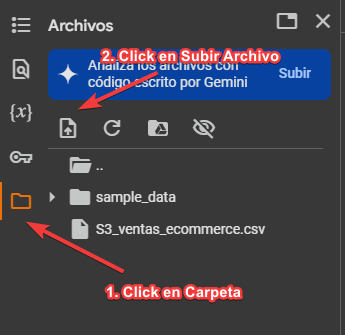

3. Importar Librería pandas
4. Crear Data frame: df -> Aquí se leen los datos usando la función read_csv y la librería Pandas
5. La función df.head() imprime las primeras 5 filas de nuestra tabla

In [2]:
import pandas as pd
df = pd.read_csv('ventas_ecommerce.csv')
df.head()


,fecha,categoria,producto,precio,cantidad,region,tipo_cliente
0,2024-01-29,Electrónica,Monitor,299.99,5,Sur,Nuevo
1,2024-01-21,Electrónica,Monitor,299.99,4,Centro,Nuevo
2,2024-01-02,Hogar,Cafetera,89.99,4,Oeste,Recurrente
3,2024-01-17,Hogar,Sábanas,35.99,3,Centro,Recurrente
4,2024-01-12,Electrónica,Tablet,399.99,4,Norte,Nuevo


#Calcular el monto de venta

Cómo hacer operaciones entre las columnas de nuestra tabla:
1. Podemos seleccionar columnas utilizando el data frame que creamos y escribiendo el nombre de la columna p.ej: `df['cantidad']`
2. Podemos crear una nueva columna en la tabla escribiendo el data frame y el nuevo nombre que tendrá nuestra columna: `df['monto_venta']`
3. Podemos asignarle el resultado de multiplicar dos columnas como cantidad y precio: `df['monto_venta'] = df['cantidad']*df['precio']`

In [3]:
df['monto_venta'] = df['cantidad']*df['precio']
df.head()

,fecha,categoria,producto,precio,cantidad,region,tipo_cliente,monto_venta
0,2024-01-29,Electrónica,Monitor,299.99,5,Sur,Nuevo,1499.95
1,2024-01-21,Electrónica,Monitor,299.99,4,Centro,Nuevo,1199.96
2,2024-01-02,Hogar,Cafetera,89.99,4,Oeste,Recurrente,359.96
3,2024-01-17,Hogar,Sábanas,35.99,3,Centro,Recurrente,107.97
4,2024-01-12,Electrónica,Tablet,399.99,4,Norte,Nuevo,1599.96


#Ventas totales por categoria

Cómo agrupar nuestros datos de acuerdo a una de nuestras columnas:
1. Creamos una nueva variable: `ventas_por_categoria`
2. Le asignamos el resultado de la función groupby. Tenemos que usar nuestro data frame para aplicar la función sobre él: `df.groupby`
3. Seleccionamos la columna que queremos utilizar para agrupar nuestros datos entre parentésis: `df.groubby('categoria')`
4. Seleccionamos la variable numérica que queremos ver entre corchetes: `df.groubpy('categoria')['monto_venta']`
5. Seleccionamos la operación que queremos realizar sobre la variable numérica: promedio: `mean()`, suma: `sum()`
6. Presentamos nuestra variable ventas_por_categoria imprimiendola con la función print

In [8]:
ventas_por_categoria = df.groupby('categoria')['monto_venta'].sum()
print(ventas_por_categoria)

categoria
Electrónica    61130.157
Hogar           7041.658
Name: monto_venta, dtype: float64


#Ticket promedio por tipo de Cliente

Igual que en el paso anterior, pero calculamos el promedio: `mean()`

In [ ]:
ticket_promedio = df.groupby('tipo_cliente')['monto_venta'].mean()
print(ticket_promedio)

tipo_cliente
Nuevo         530.844375
Premium       591.825000
Recurrente    824.605745
Name: monto_venta, dtype: float64


#Ventas por region

1. Si queremos calcular el porcentaje de ventas por región debemos primero calcular la suma de todas las ventas usando: `total_ventas = ventas_region.sum()`
2. Luego podemos dividir los valores de `ventas_region` sobre `total_ventas` y multiplicar por 100 para hallar el porcentaje

In [ ]:
ventas_region = df.groupby('region')['monto_venta'].sum()
print(ventas_region)

total_ventas = ventas_region.sum()
print("\nVentas totales:", total_ventas)

porcentaje = ((ventas_region / total_ventas) * 100).round(1)
print("\nPorcentaje de ventas por región:")
print(porcentaje)

region
Centro    14961.280
Este      11967.327
Norte     15971.293
Oeste      7769.569
Sur       17502.346
Name: monto_venta, dtype: float64

Ventas totales: 68171.815

Porcentaje de ventas por región:
region
Centro    21.9
Este      17.6
Norte     23.4
Oeste     11.4
Sur       25.7
Name: monto_venta, dtype: float64


#Productos más vendidos

Para hallar los productos más vendidos agrupamos por `producto` y `cantidad`, sumamos, y utilizamos la función `sort_values()` para organizar los resultados, si usamos el parámetro `ascending=False` se ordenan los resultados de forma descendente

In [ ]:
productos_mas_vendidos = df.groupby('producto')['cantidad'].sum().sort_values(ascending=False)
print(productos_mas_vendidos)

producto
Sábanas              29
Tablet               28
Altavoz Bluetooth    22
Smartphone           21
Monitor              20
Auriculares          20
Cámara Digital       19
Aspiradora           18
Teclado              18
Mouse                17
Lámpara LED          15
Organizador          15
Batidora             12
Smartwatch           12
Toallas              11
Sartén               11
Laptop               11
Cafetera             10
Cortinas              9
Almohada              8
Name: cantidad, dtype: int64


# Configuración para gráficos

Si queremos graficar podemos usar las librerias matplotlib o seaborn
1. Primero debemos importar las librerías
2. Definimos el tamaño de nuestro grafico en pulgadas figsize(ancho, alto): `plt.figure(figsize(10,6))`
3. Graficamos usando la función plot. Si queremos graficar ventas_por_categoria usamos: `ventas_por_categoria.plot()`. El argumento `kind=bar` define el tipo de gráfico (barras), y el argumento `color='skyblue'` define el color
4. Podemos definir un titulo para el gráfico: `plt.title()`
5. Definimos etiquetas para los ejes x e y: `plt.xlabel()`, `plt.ylabel()`


Text(0, 0.5, 'Ventas Totales ($)')

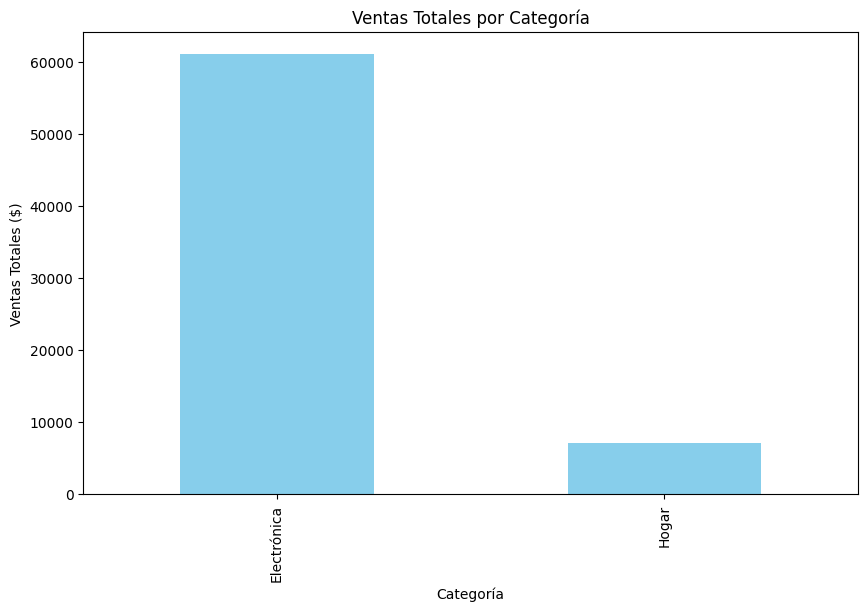

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización de ventas por categoría
plt.figure(figsize=(10, 6))
ventas_por_categoria.plot(kind='bar', color='skyblue')
plt.title('Ventas Totales por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Ventas Totales ($)')